## Planning

Jupyter notebook just for planning out matrix operations and making sure I have the right matrix dimensions, order, etc.

Disclaimer: I know partial derivatives and a reasonable amount of linear algebra but I've never had to work with partial derivatives of matrices so most of this is me going through slowly and hoping by sheer brute force that something, *anything* works.

### Architecture
- 1 input layer; 1 hidden layer; 1 output layer. 
  - 784 input nodes (each pixel in the image) (NInput)
  - 30 hidden nodes (NHidden)
  - 10 output nodes (NOutput)
- Activation function: sigmoid $\sigma(x)=\frac{1}{1+e^{-x}}$ where $\sigma(x)' = \sigma(x)\cdot (1- \sigma(x))$

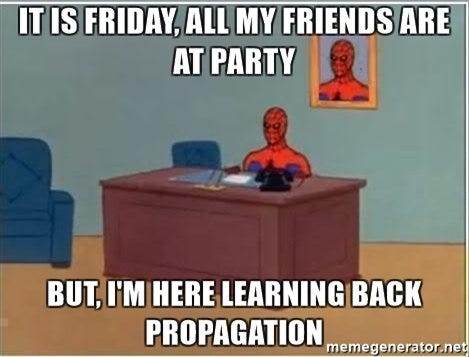

In [1]:
import numpy as np
import random

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

### Layer Equations

#### First as single example:

Layer 1:
- `(n_hidden) = (n_hidden, n_features) x (n_features) + (n_hidden)`
- $z_1 = W_1 x + b_1$
- `elementwise`
- $h_1 = \sigma(z_1)$

Layer 2:
- $z_2 = W_2 h_1 + b_2$
- No need for activation

In [3]:
n_input = 784 # (n_features)
n_hidden = 30
n_output = 10
learning_rate = 1e-2

x = np.random.normal(0, 0.01, 784)
W_1 = np.random.normal(0, 0.01, (n_hidden, n_input))
b_1 = np.random.normal(0, 0.01, n_hidden)

print(x.shape, W_1.shape, b_1.shape)

z_1 = W_1@x+b_1

print(z_1.shape)

(784,) (30, 784) (30,)
(30,)


#### Now as vectorised minibatch:

Layer 1:
- $W_1$ shape is `(n_hidden, n_features)`
- $x$ `(n_features)` is now $X$ `(n_examples, n_features)`
- In order for the dimensions to match, we can transpose $W_1$ then pre-multiply by X, yielding:
  - `(n_examples, n_features) x (n_hidden, n_features).T = (n_examples, n_features) x (n_features, n_hidden)`
  - `(n_examples, n_hidden)`
  - $Z_1 = X W_1^\top  + B_1$
  - $H_1 = \sigma(Z_1)$

Layer 2:
- $W_2$ shape is `(n_output, n_hidden)`
- $h_1$ `(n_hidden)` is now $H_1$ `(n_examples, n_hidden)`
- We can apply the same logic from layer 1 for layer 2, yielding:
  - `(n_examples, n_output)`
  - $Z_2 = H_1 W_2^\top + B_2$

In [4]:
n_examples = 32

n_input = 784 # (n_features)
n_hidden = 30
n_output = 10

X = np.random.normal(0, 0.01, (n_examples, 784))
print(f'X {X.shape}')

W_1 = np.random.normal(0, 0.01, (n_hidden, n_input))
B_1 = np.random.normal(0, 0.01, n_hidden)
print(f'W_1 {W_1.shape}, B_1 {B_1.shape}')

Z_1 = X@W_1.T+B_1
print(f'Z_1 {Z_1.shape}')

H_1 = sigmoid(Z_1)

W_2 = np.random.normal(0, 0.01, (n_output, n_hidden))
B_2 = np.random.normal(0, 0.01, n_output)
print(f'W_2 {W_2.shape}, B_2 {B_2.shape}')

Z_2 = H_1@W_2.T+B_2
print(f'Z_2 {Z_2.shape}')

X (32, 784)
W_1 (30, 784), B_1 (30,)
Z_1 (32, 30)
W_2 (10, 30), B_2 (10,)
Z_2 (32, 10)


#### Softmax

Conventionally:
$$ \hat{y}_i = \frac {e^{o_i}} {\sum_k e^{o_k}} $$

But due to overflow risk:
$$ \bar{o} \stackrel{\mathrm{def}}{=} \max_k o_k $$

$$ \hat{y}_i = \frac {e^{o_i - \bar{o}}} {\sum_k e^{o_k - \bar{o}}} $$

In [5]:
## ignore block, just for checking broadcasting was working correctly

max_values = Z_2.max(axis=1)

max_values = max_values[:, np.newaxis]

print(max_values[0:2])
Z_2[0,0] = 5
Z_2[1,0] = 10
print(Z_2[0:2,0:3])

adj_Z_2 = Z_2 - max_values

print(adj_Z_2[0:2,0:3])
print(f'max_values {max_values.shape}')

# (Z_2 - Z_2.max(axis=1)).shape

[[0.05115958]
 [0.05122341]]
[[5.00000000e+00 2.19745458e-04 5.11595780e-02]
 [1.00000000e+01 2.31226869e-04 5.12234087e-02]]
[[ 4.94884042 -0.05093983  0.        ]
 [ 9.94877659 -0.05099218  0.        ]]
max_values (32, 1)


In [ ]:
adj_Z_2 = np.exp(Z_2 - Z_2.max(axis=1)[:, np.newaxis])

print(f'adj_Z_2 {adj_Z_2.shape}')

adj_Z_2_sum = np.sum(adj_Z_2, 1)[:, np.newaxis]

print(f'adj_Z_2_sum {adj_Z_2_sum.shape}')

y_hat = adj_Z_2 / adj_Z_2_sum

print(f'y_hat {y_hat.shape}')

print(y_hat.argmax(axis=1))


adj_Z_2 (32, 10)
adj_Z_2_sum (32, 1)
y_hat (32, 10)
[0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


#### Figuring out the loss function

Cross entropy loss over an example is as follows:
$$\ell = -\sum_{j=1}^{q} y_j \cdot \log(\hat{y}_j)$$

But because $y_j$ is one-hot encoded, we can just take the value of the true class:
$$\ell = -\log(\hat{y}_j)$$

Then over the batch we can just sum up our losses:
$$\mathcal{L} = -\sum_{i=1}^{n} \log(\hat{y}_j)$$

In [7]:
# Lets generate some random one-hot encodes for testing

y = np.zeros_like(y_hat)
for i in range(y.shape[0]):
    index = random.randint(0,n_output-1)
    y[i, index] = 1

L = y * y_hat
L = L.sum(axis=1)
L = -np.log(L)
# For strict MLE should be sum but I think it's more idiomatic to use mean
L = L.mean()

L

np.float64(2.6206362522613427)

#### Figuring out backprop (loss function)

First part, figuring out how $\mathcal{L}$ changes with respect to $Z_2$

$$\frac{\partial \mathcal{L}}{\partial Z_2} = \hat{y} - y$$

In [8]:
Delta_2 = y_hat - y

print(f'partial_L {Delta_2.shape}')

partial_L (32, 10)


Second part, figuring out how to update $W_2$

$$
\begin{align}
W_2 &\leftarrow W_2 - \eta \cdot \frac{\partial \mathcal{L}} {\partial W_2} \\
W_2 &\leftarrow W_2 - \eta \cdot \frac{\partial \mathcal{L}} {\partial Z_2} \cdot \frac{\partial Z_2} {\partial W_2}
\end{align}
$$

Then recall $z_2 = W_2 h_1 + b_2;\ Z_2 = H_1 W_2^\top + B_2$ so in rough terms $\frac {\partial z_2} {\partial W_2} = h_1$ and $\frac {\partial Z_2} {\partial W_2} = H_1$

We want:
- $W_2$ is `(n_output, n_hidden)`

from:
- $\frac {\partial Z_2} {\partial W_2} = H_1$ is `(n_examples, n_hidden)`
- $\frac{\partial \mathcal{L}}{\partial Z_2}$ is `(n_examples, n_output)`

If we transpose $\frac{\partial \mathcal{L}}{\partial Z_2}$ we get `(n_output, n_examples)` so $\frac{\partial \mathcal{L}}{\partial Z_2} ^ \top \cdot H_1$ will give us `(n_output, n_hidden)`

By convention let's $\Delta_2 \stackrel{\mathrm{def}}{=} \frac{\partial \mathcal{L}}{\partial Z_2}$ and to avoid scaling weight updates with batch size we'll divide by $N$:

$$
W_2 \leftarrow W_2 - \eta \cdot \frac {1} {N} \cdot \Delta_2 ^\top \cdot H_1
$$

In [9]:
grad_W2 = (Delta_2.T @ H_1) / n_examples

print(f"grad_W2 {grad_W2.shape} W2 {W_2.shape}")

grad_W2 (10, 30) W2 (10, 30)


Third part, figuring out how to update $B_2$

$$
\begin{align}
B_2 &\leftarrow B_2 - \eta \cdot \frac{\partial \mathcal{L}} {\partial B_2} \\
B_2 &\leftarrow B_2 - \eta \cdot \frac{\partial \mathcal{L}} {\partial Z_2} \cdot \frac{\partial Z_2} {\partial B_2}
\end{align}
$$

Then recall $z_2 = W_2 h_1 + b_2;\ Z_2 = H_1 W_2^\top + B_2$ so in rough terms $\frac {\partial z_2} {\partial b_2} = 1$ and $\frac {\partial Z_2} {\partial B_2} = 1$

We want:
- $B_2$ is `(n_output)`

from:
- $\frac{\partial \mathcal{L}}{\partial Z_2} = \Delta_2$ is `(n_examples, n_output)`

If we average down the columns (axis=0) we'll get `(n_output)` to update $B_2$

Overall:

$$
B_2 \leftarrow B_2 - \eta \cdot \frac{1}{N} \cdot \text{rowsum}(\Delta_2)
$$

In [10]:
grad_B2 = Delta_2.mean(axis=0) # same as Delta_2.sum(axis=0) / n_examples

Fourth part, figuring out how to update $W_1$

$$
\begin{align}
W_1 &\leftarrow W_1 - \eta \cdot \frac{\partial \mathcal{L}} {\partial W_1} \\
W_1 &\leftarrow W_1 - \eta \cdot \frac{\partial \mathcal{L}} {\partial Z_2} \cdot \frac{\partial Z_2} {\partial H_1} \cdot \frac{\partial H_1} {\partial Z_1} \cdot \frac{\partial Z_1} {\partial W_1}
\end{align}
$$

Recall $Z_1 = X W_1^\top  + B_1;\ Z_2 = H_1 W_2^\top + B_2; \ H_1 = \sigma(Z_1)$ so roughly we have:
- $\frac{\partial \mathcal{L}} {\partial Z_2} = \Delta_2$ `(n_examples, n_output)`
- $\frac{\partial Z_2} {\partial H_1} = W_2$ `(n_output, n_hidden)`
- $\frac{\partial H_1} {\partial Z_1} = \sigma(Z_1) \cdot \left(1 - \sigma(Z_1)\right)$ `(n_examples, n_hidden; applies element wise)`
- $\frac{\partial Z_1} {\partial W_1} = X$ `(n_examples, n_input)`

We want:
- $W_1$ is `(n_hidden, n_input)`

So:
- $\Delta_2 W_2$ is `(n_examples, n_hidden)`
- $\Delta_1 \stackrel{\mathrm{def}}{=} \left(\Delta_2 W_2\right) \odot \left(\sigma(Z_1) \cdot \left(1 - \sigma(Z_1)\right)\right)$ is `(n_examples, n_hidden)`
- $\Delta_1^\top$ is `(n_hidden, n_examples)`

Overall:
$$
W_1 \leftarrow W_1 - \eta \cdot \frac{1}{N} \cdot \Delta_1^\top \cdot X
$$

In [11]:
Delta_1 = (Delta_2 @  W_2) * sigmoid(Z_1) * (1 - sigmoid(Z_1))
grad_W1 = (Delta_1.T @ X) / n_examples

Final part thank goodness, figuring out how to update $B_1$

$$
\begin{align}
B_1 &\leftarrow B_1 - \eta \cdot \frac{\partial \mathcal{L}} {\partial B_1} \\
B_1 &\leftarrow B_1 - \eta \cdot \frac{\partial \mathcal{L}} {\partial Z_2} \cdot \frac{\partial Z_2} {\partial H_1} \cdot \frac{\partial H_1} {\partial Z_1} \cdot \frac{\partial Z_1} {\partial B_1}
\end{align}
$$

We know that $\frac{\partial Z_1}{\partial B_1} = 1$ and we can steal $\Delta_1$ from the $W_1$ update equations, so now we just need to figure out the shapes:
 - $\Delta_1$ is `(n_examples, n_hidden)`

We want:
- $B_1$ is `(n_hidden)`

And we just do the same as in the third part: if we average down the columns (axis=0) we'll get `(n_hidden)` to update $B_1$

Overall:

$$
B_1 \leftarrow B_1 - \eta \cdot \frac{1}{N} \cdot \text{rowsum}(\Delta_1)
$$

In [12]:
grad_B1 = Delta_1.mean(axis=0) # same as Delta_1.sum(axis=0) / n_examples

How I feel right now:

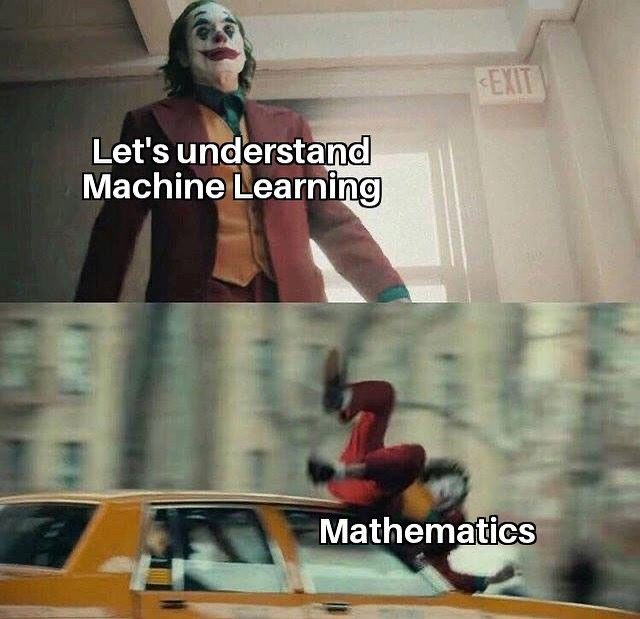